# GitHub User Field Classification

This notebook processes GitHub user data, analyzes their repository names, primary languages, descriptions, and topics, and classifies each user into a specific tech field (e.g., **AI/ML**, **Data Science**, **Web Developer**, **Cybersecurity**, **Researcher**, **System Design**, **Mobile Developer**, **Game Developer**, **Embedded/IoT**, or **Others**).

It is designed to run on the enriched user data CSV files (e.g., `docs/github_users_islamabad_full.csv`) which contain the `Repo_Metadata` and `Repo_Names` columns.

In [1]:
import pandas as pd
import numpy as np
import json
import re
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Configure the input CSV path
INPUT_CSV = "docs/github_users_islamabad_full.csv"

# Print details of the selected file
csv_path = Path(INPUT_CSV)
if csv_path.exists():
    print(f"✅ Found input CSV: {csv_path.resolve()}")
    print(f"Size: {csv_path.stat().st_size / 1024 / 1024:.2f} MB")
else:
    print(f"❌ Input CSV not found: {csv_path.resolve()}")
    print("Please check the path or ensure you have generated the full CSV file first.")

✅ Found input CSV: E:\git-city\docs\github_users_islamabad_full.csv
Size: 49.93 MB


## Keyword Heuristics and Programming Languages Mappings

We define the keyword lists for each category. Short terms (like `ai`, `ml`, `ctf`) are searched with word boundaries to avoid false positives, whereas terms with special characters (like `c++`, `c#`, `.net`) or longer phrases are matched using case-insensitive substring checks.

In [2]:
# Mappings of tech fields to keyword list
KEYWORDS = {
    "AI/ML": [
        "ai", "ml", "ai engineer", "ml engineer", "machine learning", "deep learning", "neural network", "neural networks", 
        "pytorch", "tensorflow", "keras", "scikit-learn", "sklearn", "huggingface", 
        "transformers", "llm", "llms", "gpt", "openai", "gemini", "claude", "nlp", 
        "natural language processing", "computer vision", "opencv", "yolo", "langchain", 
        "fastai", "cnn", "rnn", "lstm", "gan", "reinforcement learning", "diffusion", 
        "whisper", "chatgpt", "large language model"
    ],
    "Data Science": [
        "data science", "data analysis", "data analytics", "pandas", "numpy", "matplotlib", 
        "seaborn", "scipy", "data visualization", "jupyter", "tableau", "powerbi", 
        "analytics", "data mining", "big data", "spark", "hadoop", "pyspark", 
        "dashboard", "dashboards", "exploratory data", "eda", "data cleaning", "data pipeline", 
        "scrapper", "scraping", "web scraping", "statistics", "regression", "clustering", 
        "rstudio", "data warehouse"
    ],
    "Web Developer": [
        "web", "website", "webapps", "web app", "frontend", "front-end", "backend", "back-end", 
        "fullstack", "full-stack", "react", "angular", "vue", "svelte", "nextjs", "next.js", 
        "nuxtjs", "express", "django", "flask", "laravel", "wordpress", "wp", "html", 
        "css", "bootstrap", "tailwind", "sass", "scss", "jquery", "api", "rest api", 
        "graphql", "nodejs", "node.js", "deno", "bun", "ui", "ux", "fastapi", "spring boot", 
        "asp.net", "dotnet"
    ],
    "Cybersecurity": [
        "cybersecurity", "cyber security", "security", "cryptography", "crypto", "encryption", 
        "decryption", "hacking", "ethical hacking", "penetration testing", "pentest", 
        "pentesting", "vulnerability", "exploit", "exploits", "malware", "ctf", 
        "reverse engineering", "firewall", "network security", "cyber", "infosec", "hash", 
        "owasp", "nmap", "metasploit", "wireshark", "auth", "oauth", "jwt", "authentication", 
        "authorization", "ssh", "ssl", "tls"
    ],
    "Researcher": [
        "research", "thesis", "paper", "publication", "publications", "scientific", 
        "academic", "journal", "conference", "latex", "tex", "dissertation", "simulation", 
        "simulations", "algorithm analysis", "numerical analysis", "mathematics", "math", 
        "proof", "experiment"
    ],
    "System Design": [
        "system design", "architecture", "microservices", "distributed systems", 
        "scalability", "load balancer", "caching", "redis", "rabbitmq", "kafka", 
        "docker", "kubernetes", "aws", "gcp", "azure", "devops", "ci/cd", 
        "cloud native", "serverless", "terraform", "ansible", "system architecture", 
        "high availability"
    ],
    "Mobile Developer": [
        "mobile", "android", "ios", "swiftui", "flutter", "react native", "react-native", 
        "kotlin", "swift", "xcode", "gradle", "cocoapods", "apk", "app store", "play store", 
        "iphone", "ipad"
    ],
    "Game Developer": [
        "game", "games", "unity", "unreal", "godot", "pygame", "cogl", "phaser", "opengl", 
        "webgl", "directx", "game design", "game engine", "rpg", "arcade", "unity3d", 
        "unreal engine"
    ],
    "Embedded/IoT": [
        "embedded", "firmware", "driver", "drivers", "arduino", "raspberry pi", "iot", 
        "microcontroller", "rtos", "operating system", "kernel", "compiler", "assembler", 
        "hardware", "robotics", "verilog", "vhdl", "fpga", "esp32"
    ]
}

# Strong programming language indicators for each category
LANGUAGE_VOTES = {
    "AI/ML": ["jupyter notebook", "python"],
    "Data Science": ["jupyter notebook", "r", "matlab", "sas", "julia"],
    "Web Developer": ["javascript", "typescript", "html", "css", "php", "ruby", "vue", "svelte"],
    "Cybersecurity": [],
    "Researcher": ["tex", "latex"],
    "System Design": [],
    "Mobile Developer": ["swift", "kotlin", "dart", "objective-c"],
    "Game Developer": ["c#", "c++"],
    "Embedded/IoT": ["c", "c++", "assembly", "verilog", "vhdl", "rust"]
}

## Classification Scoring Engine

The logic parses `Repo_Metadata` for each user. For each repository, it combines its name, description, and topics into a text block and evaluates matches across all categories. 
If `Repo_Metadata` is missing or empty, it falls back to parsing the pipe-separated `Repo_Names` list.

In [3]:
def count_matches(text: str, keywords: list[str]) -> int:
    """Count case-insensitive matches of keywords in a text block, using word boundaries where appropriate."""
    text_lower = text.lower()
    matches = 0
    for kw in keywords:
        kw_lower = kw.lower()
        # Handle keywords with special characters or symbols (like C++, C#, .NET) using simple substring matching
        if any(char in kw_lower for char in ["+", "#", ".", "/", "-", " "]):
            if kw_lower in text_lower:
                matches += 1
        else:
            # Use regex with word boundaries for clean standalone words (avoid matching 'ai' in 'main', etc.)
            if re.search(r"\b" + re.escape(kw_lower) + r"\b", text_lower):
                matches += 1
    return matches

def classify_user_field(row: dict) -> str:
    """Determine the user's tech field based on Repo_Metadata or Repo_Names."""
    scores = {cat: 0 for cat in KEYWORDS.keys()}
    
    # 1. Try parsing Repo_Metadata
    metadata_raw = row.get("Repo_Metadata", "")
    repos = []
    if isinstance(metadata_raw, str) and metadata_raw.strip() not in ("", "[]", "N/A"):
        try:
            repos = json.loads(metadata_raw)
        except json.JSONDecodeError:
            pass
            
    if repos:
        # User has detailed repository metadata
        for repo in repos:
            name = repo.get("name") or ""
            desc = repo.get("description") or ""
            topics = repo.get("topics") or []
            lang = repo.get("language") or ""
            stars = int(repo.get("stars") or 0)
            
            # Combine repo text
            repo_text = f"{name} {desc} {' '.join(topics)}"
            
            for cat, kws in KEYWORDS.items():
                kw_score = count_matches(repo_text, kws)
                
                # Check for language match
                lang_score = 0
                if lang and lang.lower() in [l.lower() for l in LANGUAGE_VOTES.get(cat, [])]:
                    lang_score = 2  # Language match counts extra
                
                # Weight by stars (more popular repos represent the user's focus better)
                weight = stars + 1
                scores[cat] += (kw_score + lang_score) * weight
                
    else:
        # Fallback to Repo_Names (e.g., if Repo_Metadata is empty or missing)
        repo_names_str = row.get("Repo_Names", "")
        if isinstance(repo_names_str, str) and repo_names_str.strip() not in ("", "N/A"):
            names = repo_names_str.split("|")
            for name in names:
                for cat, kws in KEYWORDS.items():
                    scores[cat] += count_matches(name, kws)

    # 2. Heuristics fallback if all scores are 0 (e.g. check primary languages)
    max_score = max(scores.values())
    if max_score == 0:
        # Try classifying by most common language in metadata
        if repos:
            langs = [r.get("language") for r in repos if r.get("language")]
            if langs:
                primary_lang = pd.Series(langs).value_counts().index[0].lower()
                for cat, target_langs in LANGUAGE_VOTES.items():
                    if primary_lang in [t.lower() for t in target_langs]:
                        return cat
        
        # If still no classification, default to "Others"
        return "Others"
        
    # Find the category with the highest score
    best_cats = [cat for cat, score in scores.items() if score == max_score]
    return best_cats[0]

## Load CSV and Execute Classification

Let's load the data, execute the classification function on all users, and add the new `Field` column.

In [4]:
if csv_path.exists():
    # Read the full CSV
    print(f"Reading {csv_path.name}...")
    df = pd.read_csv(csv_path, keep_default_na=False)
    
    # Check if Repo_Metadata column is present
    if "Repo_Metadata" not in df.columns:
        print("⚠️ Warning: 'Repo_Metadata' column not found in this CSV.")
        print("The classification will fallback to using 'Repo_Names'.")
        print("For optimal results, please run update_missing_users.py first to fetch repository metadata.")
        
    print("Classifying users...")
    # Convert dataframe to dict list to run classifier efficiently
    records = df.to_dict(orient="records")
    fields = [classify_user_field(r) for r in records]
    df["Field"] = fields
    
    print("✅ Classification complete!")
    print(df["Field"].value_counts())
else:
    print("❌ Error: Input CSV not found. Cannot run classification.")

Reading github_users_islamabad_full.csv...


Classifying users...


✅ Classification complete!
Field
Web Developer       7422
Others              6878
AI/ML               2988
Mobile Developer     857
Game Developer       575
Data Science         330
Embedded/IoT         263
Cybersecurity         59
System Design         59
Researcher            24
Name: count, dtype: int64
✅ Classification complete!
Field
Web Developer       7422
Others              6878
AI/ML               2988
Mobile Developer     857
Game Developer       575
Data Science         330
Embedded/IoT         263
Cybersecurity         59
System Design         59
Researcher            24
Name: count, dtype: int64


## Report & Visualization

Let's generate statistical reports and visualize the distribution of fields using Seaborn.


--- User Field Breakdown ---
                  Count  Percentage (%)
Field                                  
Web Developer      7422           38.15
Others             6878           35.35
AI/ML              2988           15.36
Mobile Developer    857            4.41
Game Developer      575            2.96
Data Science        330            1.70
Embedded/IoT        263            1.35
Cybersecurity        59            0.30
System Design        59            0.30
Researcher           24            0.12

📊 Bar chart saved to: E:\git-city\docs\field_distribution_github_users_islamabad_full.png


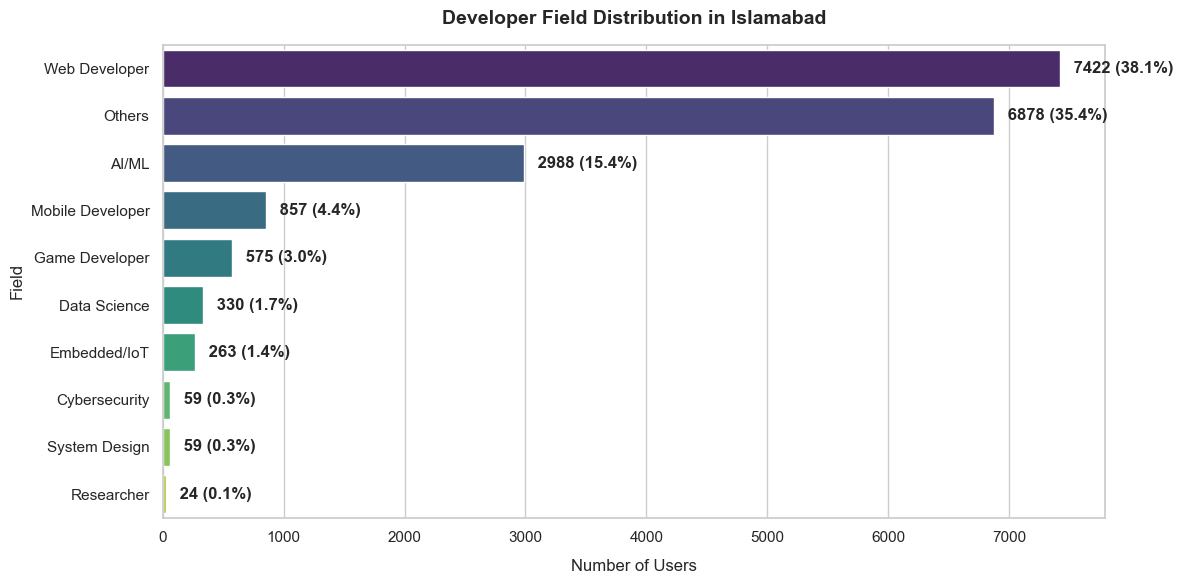

In [5]:
if csv_path.exists():
    # Calculate counts and percentages
    counts = df["Field"].value_counts()
    pcts = df["Field"].value_counts(normalize=True) * 100
    
    summary_df = pd.DataFrame({
        "Count": counts,
        "Percentage (%)": pcts.round(2)
    })
    
    print("\n--- User Field Breakdown ---")
    print(summary_df.to_string())
    
    # Set the style
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 6))
    
    # Create the horizontal bar plot
    palette = sns.color_palette("viridis", len(counts))
    ax = sns.barplot(x=counts.values, y=counts.index, hue=counts.index, palette=palette, legend=False)
    
    # Add labels and title
    plt.title(f"Developer Field Distribution in {csv_path.stem.replace('github_users_', '').replace('_full', '').title()}", fontsize=14, fontweight="bold", pad=15)
    plt.xlabel("Number of Users", fontsize=12, labelpad=10)
    plt.ylabel("Field", fontsize=12)
    
    # Add values on the bar chart
    for i, v in enumerate(counts.values):
        ax.text(v + (max(counts.values) * 0.01), i, f" {v} ({pcts.values[i]:.1f}%)", va="center", fontweight="semibold")
        
    plt.tight_layout()
    
    # Save the plot image
    plot_img_path = csv_path.parent / f"field_distribution_{csv_path.stem}.png"
    plt.savefig(plot_img_path, dpi=150, bbox_inches="tight")
    print(f"\n📊 Bar chart saved to: {plot_img_path.resolve()}")
    plt.show()

## Save the Updated CSV File

We will save the classified records back to the source CSV. This will include the new `Field` column.

In [6]:
if csv_path.exists():
    # Export back to the CSV
    df.to_csv(csv_path, index=False)
    print(f"🎉 Successfully saved updated data with 'Field' column to: {csv_path.resolve()}")

🎉 Successfully saved updated data with 'Field' column to: E:\git-city\docs\github_users_islamabad_full.csv
